In [90]:
import os
import yaml
import pandas as pd

In [2]:
main_folder = r"C:\Users\admin\Downloads\data"

In [3]:
import os
import yaml
import pandas as pd
main_folder = r"C:\Users\admin\Downloads\data"
all_stock_data = []

folders = os.listdir(main_folder)

for folder in folders:

    folder_path = os.path.join(main_folder, folder)

    files = os.listdir(folder_path)

    for file in files:

        if file.endswith(".yaml"):

            file_path = os.path.join(folder_path, file)

            with open(file_path, "r") as f:

                data = yaml.safe_load(f)

                all_stock_data.extend(data)


df = pd.DataFrame(all_stock_data)

print(df.head())

print(df.shape)

print(df.columns)

       Ticker    close                 date    high      low    month    open  \
0        SBIN   602.95  2023-10-03 05:30:00   604.9   589.60  2023-10   596.6   
1  BAJFINANCE  7967.60  2023-10-03 05:30:00  7975.5  7755.00  2023-10  7780.8   
2       TITAN  3196.25  2023-10-03 05:30:00  3212.5  3114.40  2023-10  3148.8   
3         ITC   439.75  2023-10-03 05:30:00   442.9   439.25  2023-10   441.0   
4         TCS  3513.85  2023-10-03 05:30:00  3534.2  3480.10  2023-10  3534.2   

     volume  
0  15322196  
1    944555  
2   1007308  
3   7481883  
4   1948148  
(14200, 8)
Index(['Ticker', 'close', 'date', 'high', 'low', 'month', 'open', 'volume'], dtype='object')


In [4]:
df.to_csv("nifty50_stock_data.csv", index=False)

In [5]:
import os

print("nifty50_stock_data.csv" in os.listdir())

True


In [13]:
df.shape

(14200, 8)

In [91]:
df.isnull().sum()

Ticker               0
close                0
date                 0
high                 0
low                  0
month                0
open                 0
volume               0
daily_return         0
cumulative_return    0
monthly_return       0
Yearly_Return        0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

Ticker     object
close     float64
date       object
high      float64
low       float64
month      object
open      float64
volume      int64
dtype: object

In [21]:
df['date'] = pd.to_datetime(df['date'])

In [22]:
df['month'] = df['date'].dt.month

In [17]:
df.dtypes

Ticker     object
close     float64
date       object
high      float64
low       float64
month      object
open      float64
volume      int64
dtype: object

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14200 entries, 0 to 14199
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  14200 non-null  object 
 1   close   14200 non-null  float64
 2   date    14200 non-null  object 
 3   high    14200 non-null  float64
 4   low     14200 non-null  float64
 5   month   14200 non-null  object 
 6   open    14200 non-null  float64
 7   volume  14200 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 887.6+ KB


In [21]:
print(df.head())

       Ticker    close                date    high      low    month    open  \
0        SBIN   602.95 2023-10-03 05:30:00   604.9   589.60  2023-10   596.6   
1  BAJFINANCE  7967.60 2023-10-03 05:30:00  7975.5  7755.00  2023-10  7780.8   
2       TITAN  3196.25 2023-10-03 05:30:00  3212.5  3114.40  2023-10  3148.8   
3         ITC   439.75 2023-10-03 05:30:00   442.9   439.25  2023-10   441.0   
4         TCS  3513.85 2023-10-03 05:30:00  3534.2  3480.10  2023-10  3534.2   

     volume  
0  15322196  
1    944555  
2   1007308  
3   7481883  
4   1948148  


In [23]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

In [24]:
df.dtypes


Ticker            object
close            float64
date      datetime64[ns]
high             float64
low              float64
month          period[M]
open             float64
volume             int64
dtype: object

In [56]:
df.to_csv("all_stock_data.csv", index=False)

In [57]:
df = df.sort_values(by=['Ticker', 'date'])

In [25]:
print(df.head())

       Ticker    close                date    high      low    month    open  \
0        SBIN   602.95 2023-10-03 05:30:00   604.9   589.60  2023-10   596.6   
1  BAJFINANCE  7967.60 2023-10-03 05:30:00  7975.5  7755.00  2023-10  7780.8   
2       TITAN  3196.25 2023-10-03 05:30:00  3212.5  3114.40  2023-10  3148.8   
3         ITC   439.75 2023-10-03 05:30:00   442.9   439.25  2023-10   441.0   
4         TCS  3513.85 2023-10-03 05:30:00  3534.2  3480.10  2023-10  3534.2   

     volume  
0  15322196  
1    944555  
2   1007308  
3   7481883  
4   1948148  


In [27]:
df = df.sort_values(by=['Ticker', 'date']).reset_index(drop=True)
print(df.head())

     Ticker    close                date     high      low    month     open  \
0  ADANIENT  2387.25 2023-10-03 05:30:00  2424.90  2372.00  2023-10  2418.00   
1  ADANIENT  2464.95 2023-10-04 05:30:00  2502.75  2392.25  2023-10  2402.20   
2  ADANIENT  2466.35 2023-10-05 05:30:00  2486.50  2446.40  2023-10  2477.95   
3  ADANIENT  2478.10 2023-10-06 05:30:00  2514.95  2466.05  2023-10  2466.35   
4  ADANIENT  2442.60 2023-10-09 05:30:00  2459.70  2411.30  2023-10  2440.00   

    volume  
0  2019899  
1  2857377  
2  1132455  
3  1510035  
4  1408224  


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'final_stock_data.csv', 'nifty50_stock_data.csv', 'Untitled.ipynb']


In [30]:
# daily returns for each stock
df['daily_return'] = (
    df.groupby('Ticker')['close']
    .pct_change()
)

In [64]:
volatility = df.groupby('Ticker')['daily_return'].std()
print(volatility)

Ticker
ADANIENT      0.028601
ADANIPORTS    0.026029
APOLLOHOSP    0.014135
ASIANPAINT    0.012665
AXISBANK      0.015625
BAJAJ-AUTO    0.017609
BAJAJFINSV    0.014118
BAJFINANCE    0.015918
BEL           0.023283
BHARTIARTL    0.013625
BPCL          0.022069
BRITANNIA     0.013039
CIPLA         0.016332
COALINDIA     0.021411
DRREDDY       0.012490
EICHERMOT     0.016099
GRASIM        0.014465
HCLTECH       0.014295
HDFCBANK      0.013490
HDFCLIFE      0.014630
HEROMOTOCO    0.016563
HINDALCO      0.019587
HINDUNILVR    0.012074
ICICIBANK     0.012789
INDUSINDBK    0.019111
INFY          0.014492
ITC           0.011944
JSWSTEEL      0.016384
KOTAKBANK     0.014216
LT            0.016964
M&M           0.019213
MARUTI        0.013712
NESTLEIND     0.012517
NTPC          0.019475
ONGC          0.022247
POWERGRID     0.018671
RELIANCE      0.013562
SBILIFE       0.015113
SBIN          0.017939
SHRIRAMFIN    0.021687
SUNPHARMA     0.011733
TATACONSUM    0.014805
TATAMOTORS    0.017877
TATA

In [93]:
top_10_volatile = volatility.sort_values(ascending=False).head(10)

print(top_10_volatile)

Ticker
ADANIENT      0.028550
ADANIPORTS    0.025983
BEL           0.023243
TRENT         0.023034
ONGC          0.022208
BPCL          0.022030
SHRIRAMFIN    0.021649
COALINDIA     0.021374
HINDALCO      0.019552
NTPC          0.019441
Name: daily_return, dtype: float64


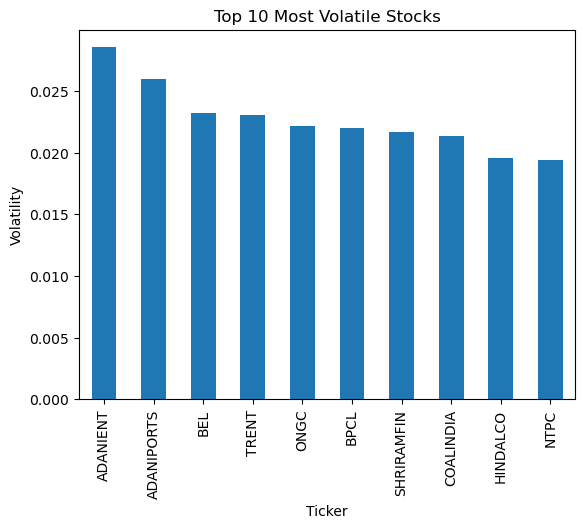

In [94]:
import matplotlib.pyplot as plt

top_10_volatile.plot(kind='bar')

plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Ticker")
plt.ylabel("Volatility")

plt.show()

In [69]:
df.describe()

,close,high,low,open,volume,daily_return
count,14200.000000,14200.000000,14200.000000,14200.000000,1.420000e+04,14150.000000
mean,2449.415380,2476.495940,2422.374544,2450.982693,6.833475e+06,0.001025
std,2573.791109,2601.744121,2545.346794,2575.276197,1.129303e+07,0.017004
min,116.600000,118.550000,114.600000,114.600000,5.987000e+03,-0.226068
25%,821.850000,831.900000,814.500000,824.775000,9.636955e+05,-0.007555
50%,1508.175000,1523.875000,1493.315000,1510.000000,2.446882e+06,0.000637
75%,3101.762500,3138.150000,3066.062500,3101.837500,8.592909e+06,0.009211
max,13495.600000,13680.000000,13274.450000,13393.000000,2.680527e+08,0.188633


In [32]:
df['cumulative_return'] = df.groupby('Ticker')['daily_return'].transform(lambda x: (1 + x).cumprod())

In [33]:
final = df.groupby('Ticker')['cumulative_return'].last()

top5 = final.sort_values(ascending=False).head(5)

print(top5)

Ticker
TRENT         3.230926
BEL           2.017601
M&M           1.959770
BAJAJ-AUTO    1.890112
BHARTIARTL    1.695990
Name: cumulative_return, dtype: float64


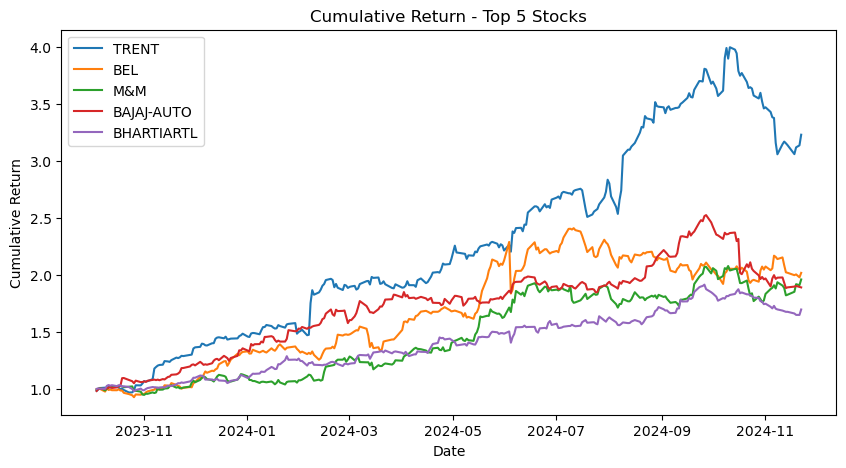

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for stock in top5_stocks:
    data = df_top5[df_top5['Ticker'] == stock]
    plt.plot(data['date'], data['cumulative_return'], label=stock)

plt.title("Cumulative Return - Top 5 Stocks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

In [36]:
 #Sector-wise Performance:
yearly = df.groupby('Ticker').apply(
    lambda x: ((x['close'].iloc[-1] - x['close'].iloc[0]) / x['close'].iloc[0]) * 100
).reset_index(name='Yearly_Return')

print(yearly)


        Ticker  Yearly_Return
0     ADANIENT      -6.670856
1   ADANIPORTS      36.727207
2   APOLLOHOSP      35.478956
3   ASIANPAINT     -21.935046
4     AXISBANK       9.735363
5   BAJAJ-AUTO      89.011153
6   BAJAJFINSV       2.549566
7   BAJFINANCE     -16.110874
8          BEL     101.760057
9   BHARTIARTL      69.599049
10        BPCL      67.477150
11   BRITANNIA       7.850160
12       CIPLA      25.676361
13   COALINDIA      41.846523
14     DRREDDY      11.178754
15   EICHERMOT      48.779614
16      GRASIM      35.781988
17     HCLTECH      53.257447
18    HDFCBANK      15.752130
19    HDFCLIFE       8.625996
20  HEROMOTOCO      58.976655
21    HINDALCO      35.868320
22  HINDUNILVR      -0.957916
23   ICICIBANK      35.919387
24  INDUSINDBK     -30.458409
25        INFY      32.653417
26         ITC       7.936327
27    JSWSTEEL      26.887374
28   KOTAKBANK       1.991836
29          LT      17.253722
30         M&M      95.976974
31      MARUTI       6.926712
32   NESTL

C:\Users\admin\AppData\Local\Temp\ipykernel_8004\2822090215.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly = df.groupby('Ticker').apply(


In [37]:
sector_data = {
    'Ticker':  ['ADANIENT','ADANIPORTS','APOLLOHOSP','ASIANPAINT','AXISBANK',
                'BAJAJ-AUTO','BAJAJFINSV','BAJFINANCE','BEL','BHARTIARTL',
                'BPCL','BRITANNIA','CIPLA','COALINDIA','DRREDDY',
                'EICHERMOT','GRASIM','HCLTECH','HDFCBANK','HDFCLIFE',
                'HEROMOTOCO','HINDALCO','HINDUNILVR','ICICIBANK','INDUSINDBK',
                'INFY','ITC','JSWSTEEL','KOTAKBANK','LT',
                'M&M','MARUTI','NESTLEIND','NTPC','ONGC',
                'POWERGRID','RELIANCE','SBILIFE','SBIN','SHRIRAMFIN',
                'SUNPHARMA','TATACONSUM','TATAMOTORS','TATASTEEL','TCS',
                'TECHM','TITAN','TRENT','ULTRACEMCO','WIPRO'],

    'Sector':  ['Energy','Infrastructure','Healthcare','Consumer Goods','Financials',
                'Automobile','Financials','Financials','Defence','Telecom',
                'Energy','Consumer Goods','Healthcare','Energy','Healthcare',
                'Automobile','Cement','IT','Financials','Financials',
                'Automobile','Metals','Consumer Goods','Financials','Financials',
                'IT','Consumer Goods','Metals','Financials','Infrastructure',
                'Automobile','Automobile','Consumer Goods','Energy','Energy',
                'Energy','Energy','Financials','Financials','Financials',
                'Healthcare','Consumer Goods','Automobile','Metals','IT',
                'IT','Consumer Goods','Retail','Cement','IT']
}

sector_df = pd.DataFrame(sector_data)
print(sector_df)

        Ticker          Sector
0     ADANIENT          Energy
1   ADANIPORTS  Infrastructure
2   APOLLOHOSP      Healthcare
3   ASIANPAINT  Consumer Goods
4     AXISBANK      Financials
5   BAJAJ-AUTO      Automobile
6   BAJAJFINSV      Financials
7   BAJFINANCE      Financials
8          BEL         Defence
9   BHARTIARTL         Telecom
10        BPCL          Energy
11   BRITANNIA  Consumer Goods
12       CIPLA      Healthcare
13   COALINDIA          Energy
14     DRREDDY      Healthcare
15   EICHERMOT      Automobile
16      GRASIM          Cement
17     HCLTECH              IT
18    HDFCBANK      Financials
19    HDFCLIFE      Financials
20  HEROMOTOCO      Automobile
21    HINDALCO          Metals
22  HINDUNILVR  Consumer Goods
23   ICICIBANK      Financials
24  INDUSINDBK      Financials
25        INFY              IT
26         ITC  Consumer Goods
27    JSWSTEEL          Metals
28   KOTAKBANK      Financials
29          LT  Infrastructure
30         M&M      Automobile
31      

In [38]:
merged = pd.merge(yearly, sector_df, on='Ticker')
print(merged)

        Ticker  Yearly_Return          Sector
0     ADANIENT      -6.670856          Energy
1   ADANIPORTS      36.727207  Infrastructure
2   APOLLOHOSP      35.478956      Healthcare
3   ASIANPAINT     -21.935046  Consumer Goods
4     AXISBANK       9.735363      Financials
5   BAJAJ-AUTO      89.011153      Automobile
6   BAJAJFINSV       2.549566      Financials
7   BAJFINANCE     -16.110874      Financials
8          BEL     101.760057         Defence
9   BHARTIARTL      69.599049         Telecom
10        BPCL      67.477150          Energy
11   BRITANNIA       7.850160  Consumer Goods
12       CIPLA      25.676361      Healthcare
13   COALINDIA      41.846523          Energy
14     DRREDDY      11.178754      Healthcare
15   EICHERMOT      48.779614      Automobile
16      GRASIM      35.781988          Cement
17     HCLTECH      53.257447              IT
18    HDFCBANK      15.752130      Financials
19    HDFCLIFE       8.625996      Financials
20  HEROMOTOCO      58.976655     

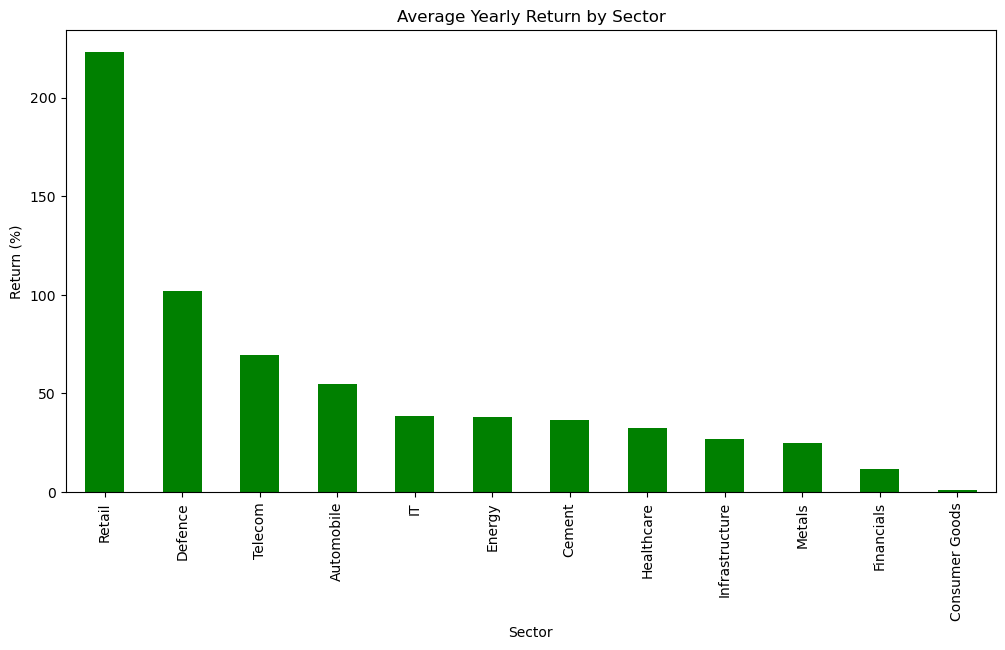

In [39]:
sector_avg = merged.groupby('Sector')['Yearly_Return'].mean().sort_values(ascending=False)

colors = ['green' if x > 0 else 'red' for x in sector_avg]

sector_avg.plot(kind='bar', color=colors, figsize=(12,6))
plt.title("Average Yearly Return by Sector")
plt.xlabel("Sector")
plt.ylabel("Return (%)")


plt.show()

In [40]:
# Stock Price Correlation:
pivot = df.pivot_table(index='date', columns='Ticker', values='close')
print(pivot.head())

Ticker               ADANIENT  ADANIPORTS  APOLLOHOSP  ASIANPAINT  AXISBANK  \
date                                                                          
2023-10-03 05:30:00   2387.25      831.40     5118.95     3166.85   1041.05   
2023-10-04 05:30:00   2464.95      824.60     5047.40     3169.90    995.55   
2023-10-05 05:30:00   2466.35      825.20     5047.05     3206.25   1003.25   
2023-10-06 05:30:00   2478.10      830.75     5060.25     3195.75   1000.95   
2023-10-09 05:30:00   2442.60      790.05     5047.30     3152.80    996.25   

Ticker               BAJAJ-AUTO  BAJAJFINSV  BAJFINANCE     BEL  BHARTIARTL  \
date                                                                          
2023-10-03 05:30:00     5016.45     1561.05     7967.60  139.20      925.30   
2023-10-04 05:30:00     4918.60     1532.55     7854.05  138.85      924.25   
2023-10-05 05:30:00     5011.05     1542.55     7850.90  138.95      928.85   
2023-10-06 05:30:00     5014.60     1634.65     816

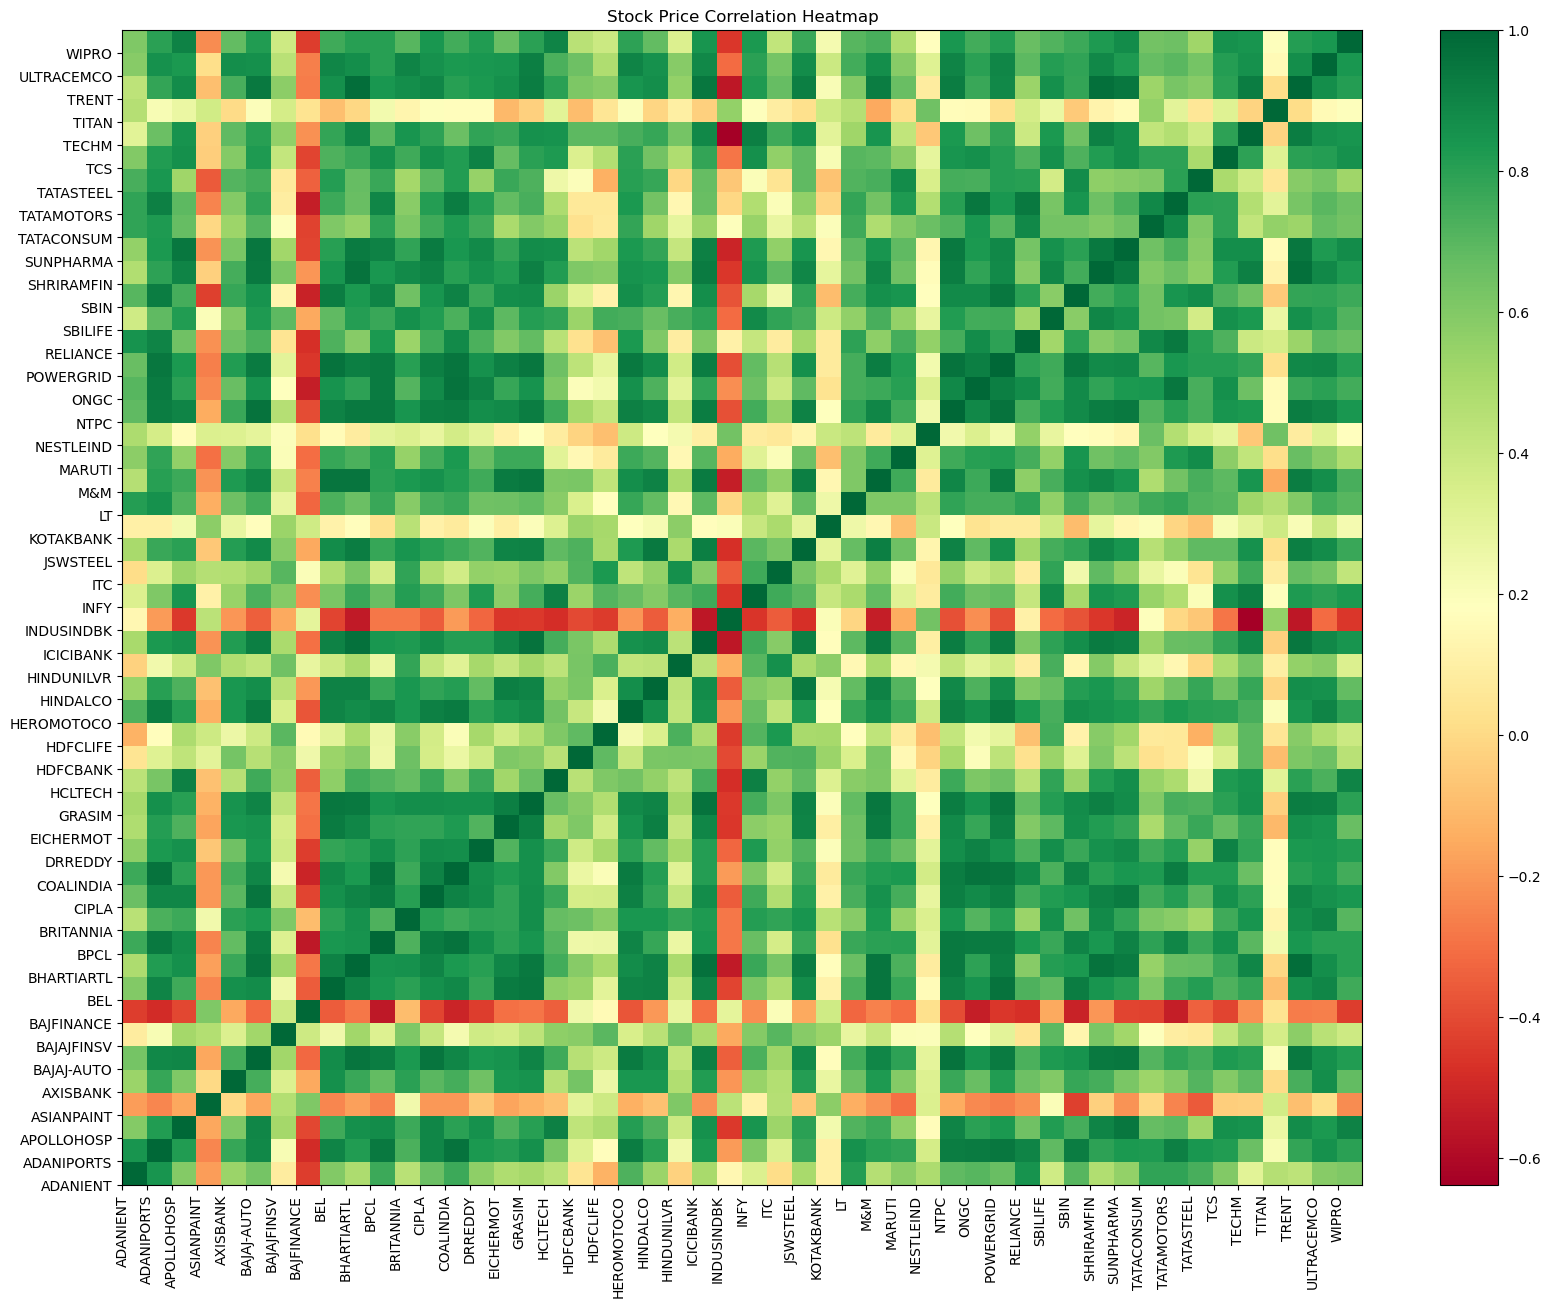

In [44]:
plt.figure(figsize=(20, 15))
plt.pcolor(corr_matrix, cmap='RdYlGn')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Stock Price Correlation Heatmap")

plt.show()

In [55]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
monthly_return = df.groupby(['Ticker', 'month'])['close'].apply(
    lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100
).reset_index(name='Monthly_Return')

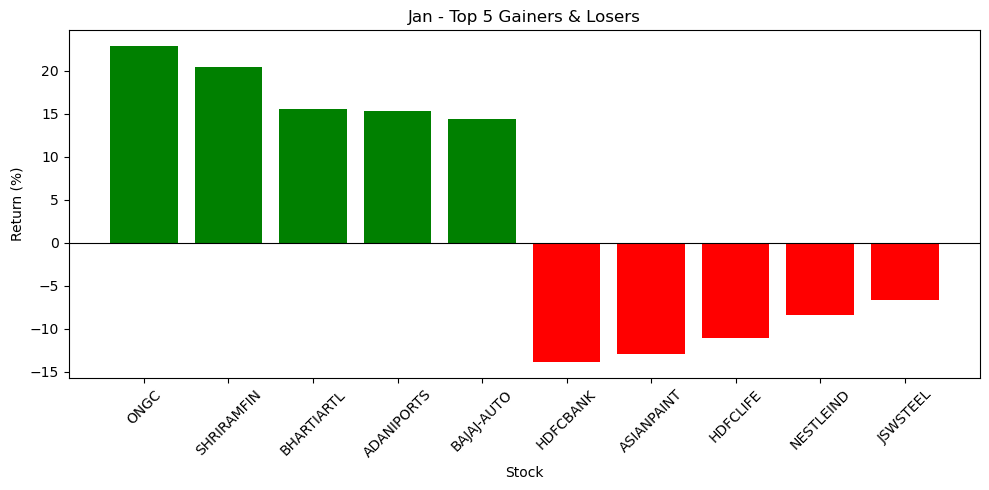

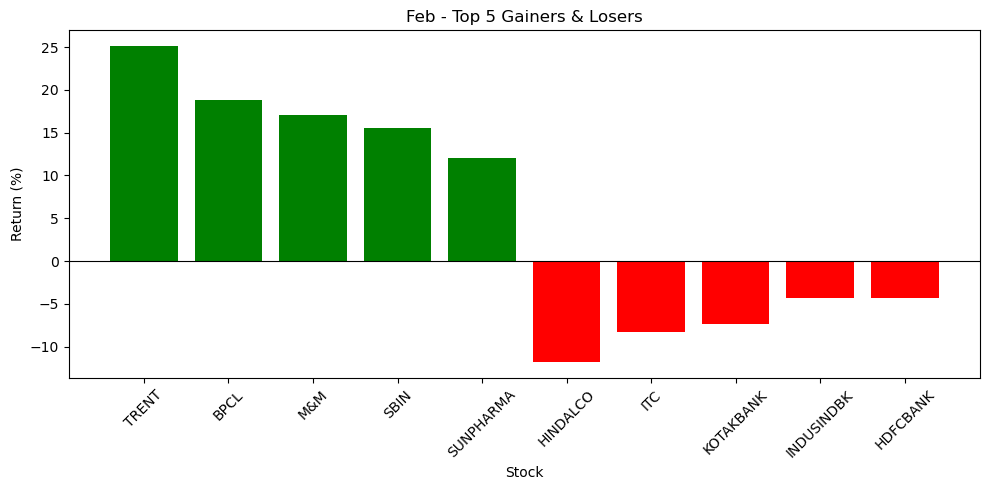

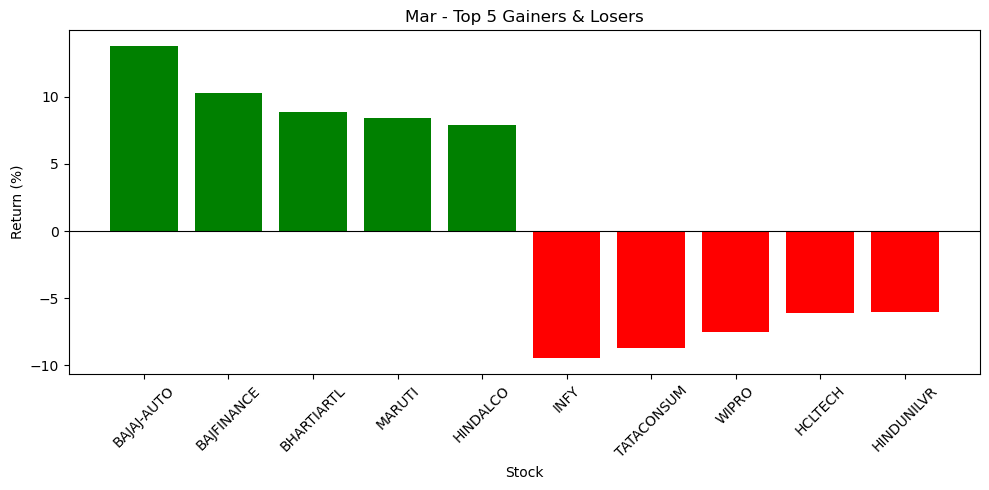

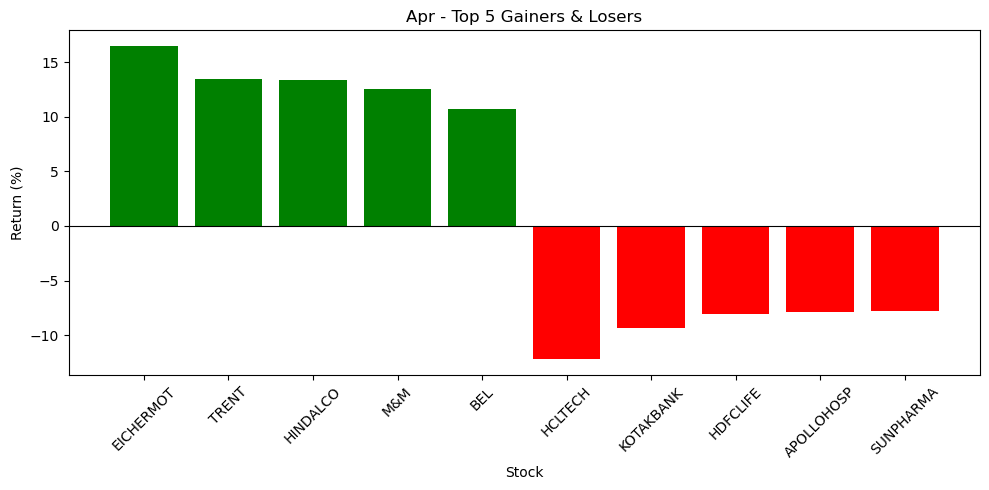

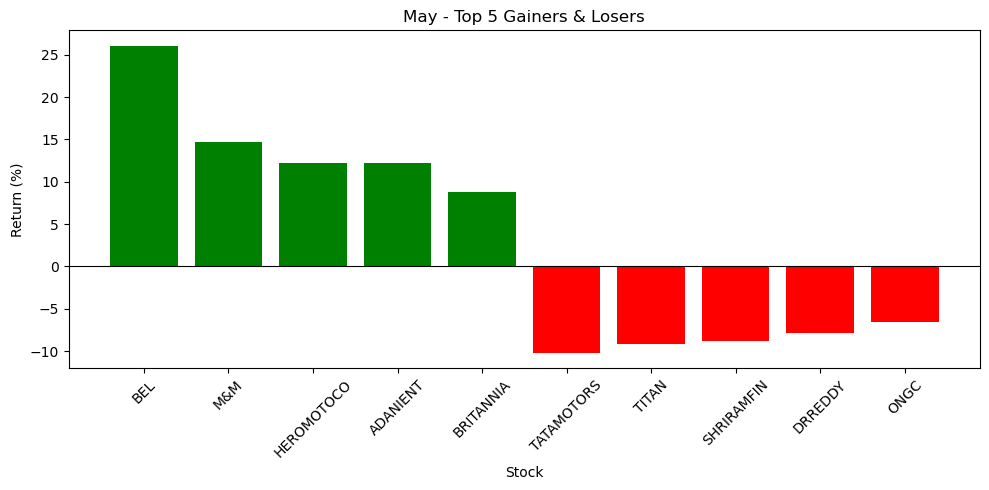

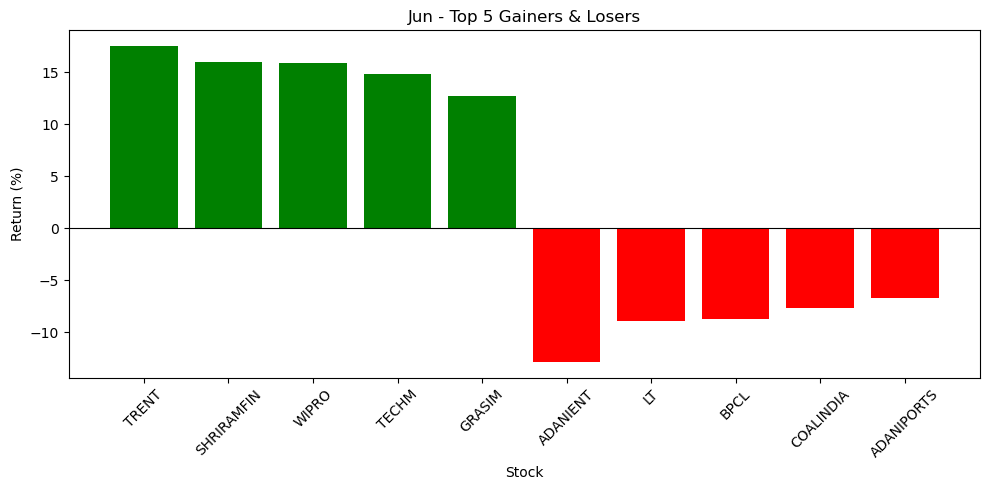

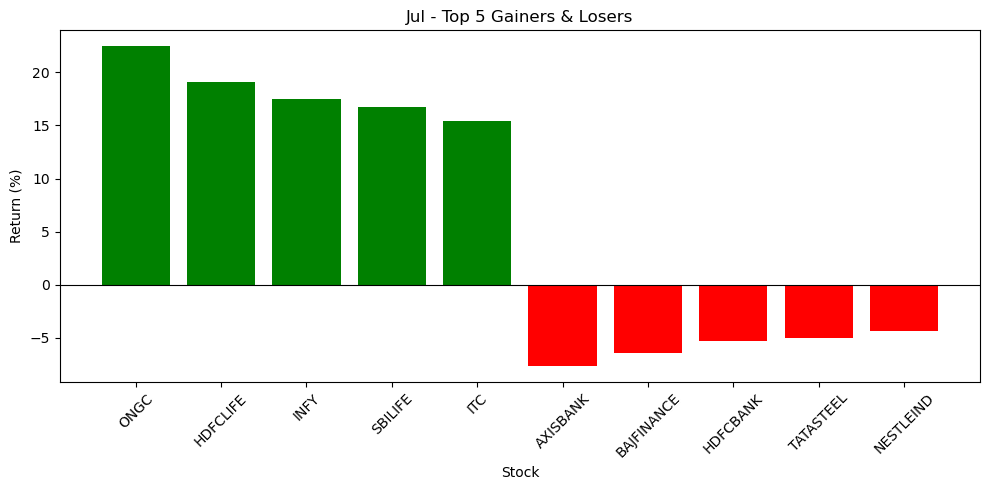

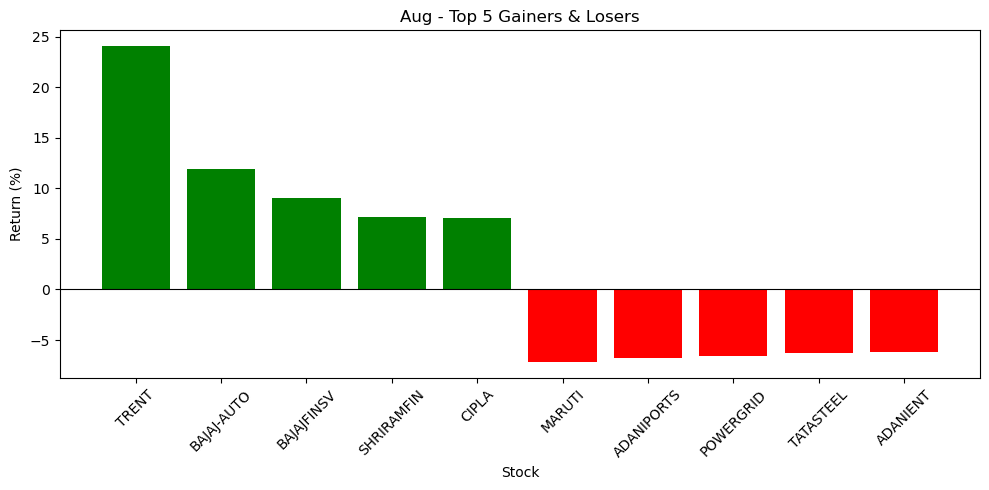

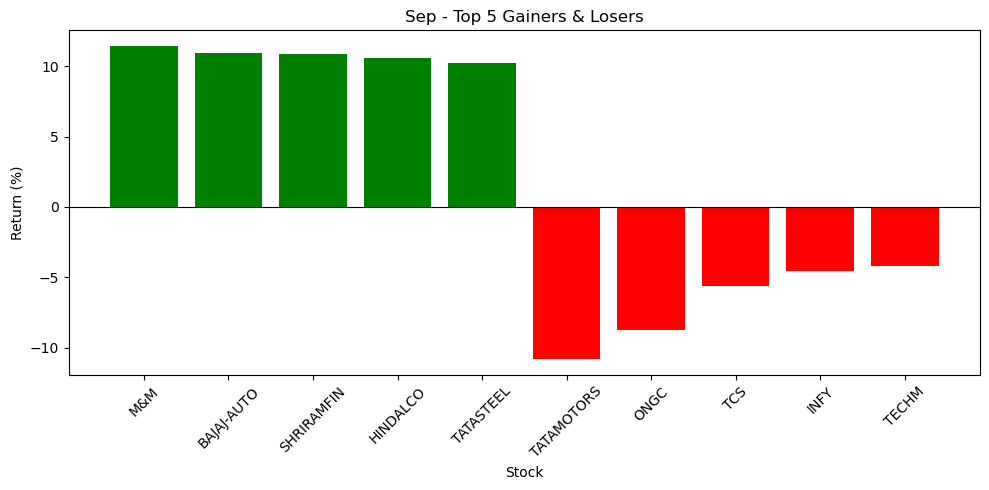

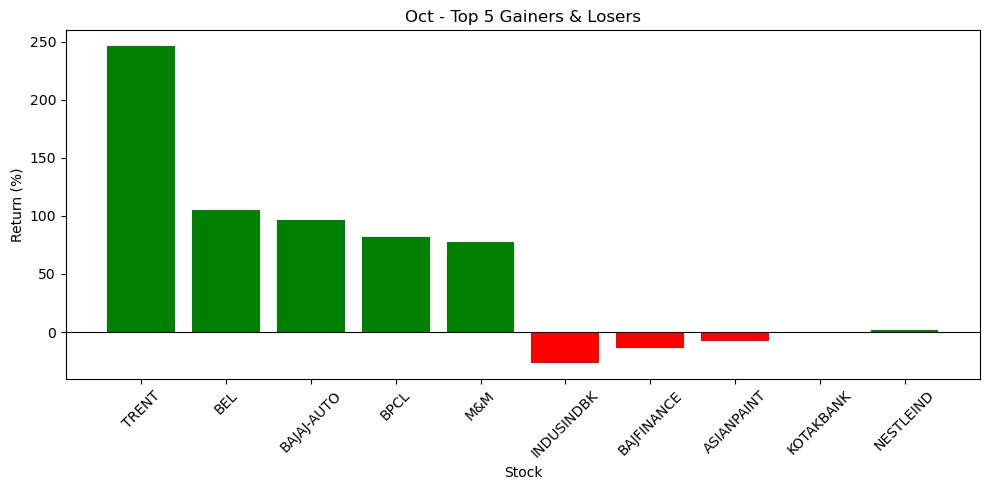

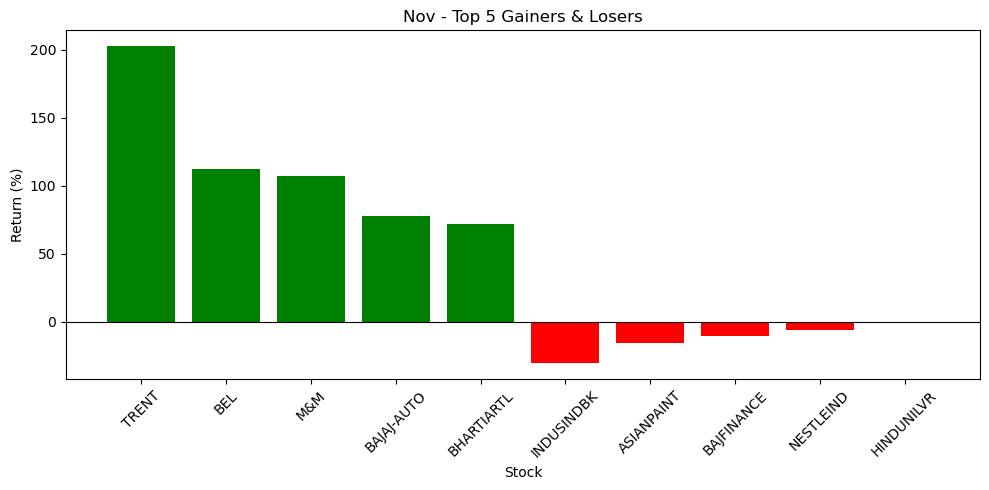

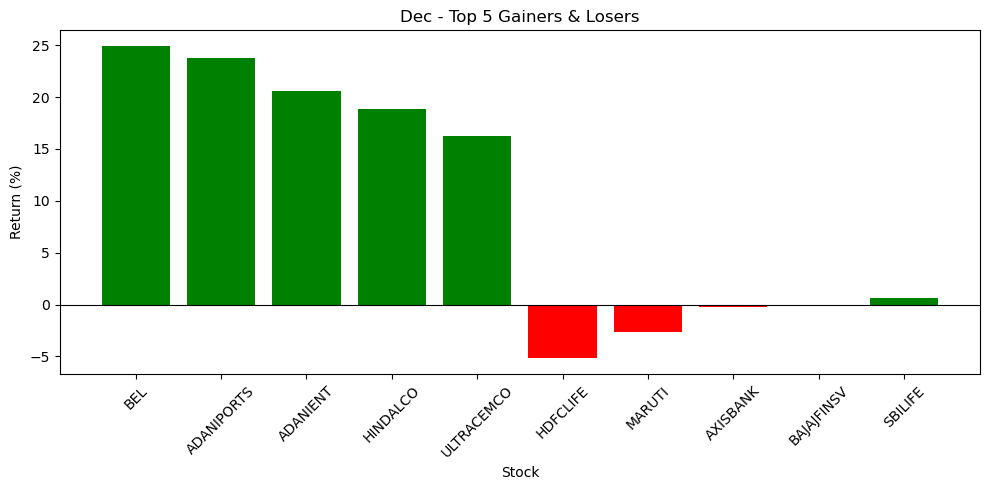

In [57]:
months = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
          7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

for month in range(1, 13):
    gainers = top5_gainers[top5_gainers['month'] == month]
    losers = top5_losers[top5_losers['month'] == month]
    
    combined = pd.concat([gainers, losers])
    colors = ['green' if x > 0 else 'red' for x in combined['Monthly_Return']]
    
    plt.figure(figsize=(10, 5))
    plt.bar(combined['Ticker'], combined['Monthly_Return'], color=colors)
    plt.title(f"{months[month]} - Top 5 Gainers & Losers")
    plt.xlabel("Stock")
    plt.ylabel("Return (%)")
    plt.xticks(rotation=45)
    plt.axhline(y=0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

In [59]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [97]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.environ.get("DB_PASSWORD", "Ygn@1994"),
    database="stock_project"
)

print("Connected")

Connected


In [60]:
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS stock_data (
        Ticker VARCHAR(20),
        close FLOAT,
        date DATETIME,
        high FLOAT,
        low FLOAT,
        month INT,
        open FLOAT,
        volume BIGINT,
        daily_return FLOAT
    )
""")



In [67]:
data = []
for index, row in df.iterrows():
    data.append((
        row['Ticker'],
        row['close'],
        str(row['date']),
        row['high'],
        row['low'],
        row['month'],
        row['open'],
        row['volume'],
        row['daily_return']
    ))

cursor.executemany("""
    INSERT INTO stock_data 
    (Ticker, close, date, high, low, month, open, volume, daily_return)
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
""", data)

conn.commit()


In [71]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [118]:
import pandas as pd

df = pd.read_csv("final_stock_data.csv")
df.head()

,Ticker,close,date,high,low,month,open,volume,daily_return,cumulative_return,Yearly_Return,monthly_return
0,ADANIENT,2387.25,2023-10-03 05:30:00,2424.90,2372.00,10,2418.00,2019899,0.000000,1.000000,-6.670856,23.457954
1,ADANIENT,2464.95,2023-10-04 05:30:00,2502.75,2392.25,10,2402.20,2857377,0.032548,1.032548,-6.670856,23.457954
2,ADANIENT,2466.35,2023-10-05 05:30:00,2486.50,2446.40,10,2477.95,1132455,0.000568,1.033134,-6.670856,23.457954
3,ADANIENT,2478.10,2023-10-06 05:30:00,2514.95,2466.05,10,2466.35,1510035,0.004764,1.038056,-6.670856,23.457954
4,ADANIENT,2442.60,2023-10-09 05:30:00,2459.70,2411.30,10,2440.00,1408224,-0.014325,1.023186,-6.670856,23.457954
